In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
raw_shark_df = pd.read_csv("../data/clean_data/clean_data.csv")
shark_df = raw_shark_df.drop(["type", "country", "state"], axis=1)

print(shark_df.head(), "\n")

nonfatal_df = shark_df[shark_df["fatal"] == "N"]
fatal_df = shark_df[shark_df["fatal"] == "Y"]

# compute overall statistics
total_attacks = len(shark_df)
total_fatal = len(fatal_df)
total_nonfatal = len(nonfatal_df)
prop_fatal = total_fatal / total_attacks

print(f"Total number of attacks: {total_attacks}")
print(f"Number of fatal attacks: {total_fatal}")
print(f"Number of nonfatal attacks: {total_nonfatal}")
print(f"Overall fatality rate: {prop_fatal:.2%}")

   activity  sex   age fatal       time      species  year  month
0  swimming    m  12.0     N  afternoon          NaN   NaN    6.0
1  swimming    f  17.0     N    morning          NaN   NaN    6.0
2  swimming    f  35.0     N    morning  great white   NaN    6.0
3  swimming    f   NaN     N  afternoon          NaN   NaN    6.0
4  swimming  NaN   NaN     N    morning         bull   NaN    6.0 

Total number of attacks: 5164
Number of fatal attacks: 1273
Number of nonfatal attacks: 3891
Overall fatality rate: 24.65%


## Activity Analysis

In [30]:
activity_counts = fatal_df.groupby("activity").size().to_frame(name="fatal_count").reset_index()
activity_counts["nonfatal_count"] = nonfatal_df.groupby("activity").size().to_list()
activity_counts["total_count"] = activity_counts["fatal_count"] + activity_counts["nonfatal_count"]
activity_counts["fatality_rate"] = activity_counts["fatal_count"] / activity_counts["total_count"]
activity_counts["perc_of_total"] = activity_counts["total_count"] / total_attacks

# drop activities that account for less than 1% of attacks
activity_counts = activity_counts[activity_counts["perc_of_total"] >= 0.01]
activity_counts.drop(["perc_of_total"], axis=1, inplace=True)

# drop adrift due to uncertainty of circumstances
activity_counts = activity_counts[activity_counts["activity"] != "adrift"]

# sort for visuals
activity_counts.sort_values("total_count", ascending=True, inplace=True)

activity_counts

,activity,fatal_count,nonfatal_count,total_count,fatality_rate
6,small watercraft,14,71,85,0.164706
4,fishing,74,188,262,0.282443
2,dive fishing,71,326,397,0.178841
3,diving,135,325,460,0.293478
9,wading,153,464,617,0.247974
8,swimming,437,870,1307,0.334353
7,surfing/bodyboarding,108,1254,1362,0.079295


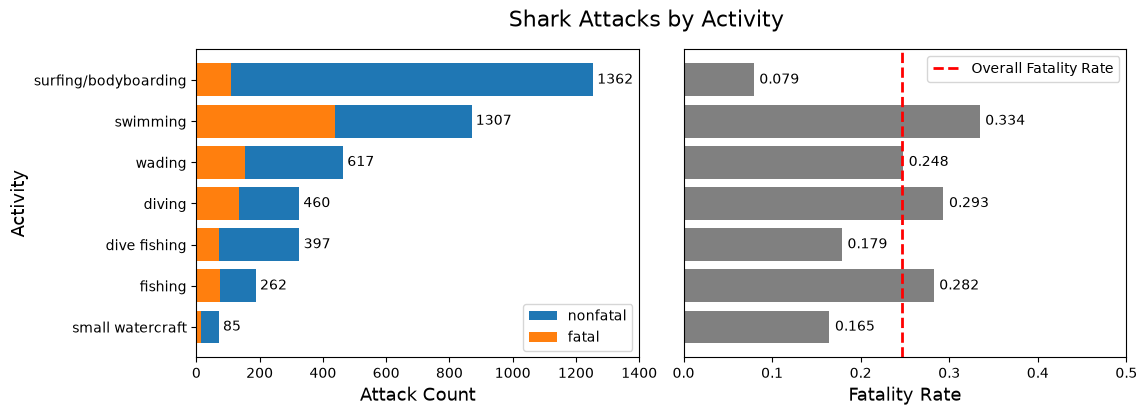

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), gridspec_kw={'wspace': 0.1})

# bar chart for totals
b1 = axes[0].barh(
    activity_counts["activity"],
    activity_counts["nonfatal_count"],
    label="nonfatal"
)
b2 = axes[0].barh(
    activity_counts["activity"],
    activity_counts["fatal_count"],
    label="fatal"
)
axes[0].bar_label(axes[0].containers[0], labels=activity_counts["total_count"], padding=3)
axes[0].set_xlim(0, 1400)
axes[0].legend()


# bar chart for death rates
b3 = axes[1].barh(
    activity_counts["activity"],
    activity_counts["fatality_rate"],
    color="gray"
)
plt.axvline(x=prop_fatal, color='red', linestyle='--', linewidth=2, label='Overall Fatality Rate')
axes[1].bar_label(axes[1].containers[0], fmt='%.3f', padding=4)
axes[1].set_yticks([])
axes[1].set_xlim(0, 0.5)
axes[1].legend()


# set labels and titles
axes[0].set_ylabel("Activity", fontsize=13)
axes[0].set_xlabel("Attack Count", fontsize=13)
axes[1].set_xlabel("Fatality Rate", fontsize=13)
fig.suptitle("Shark Attacks by Activity", fontsize=16)

plt.show()